In [3]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

base = '/content/drive/MyDrive/race_rc_project'

train_df = pd.read_csv(f'{base}/data/raw/train.csv')
test_df  = pd.read_csv(f'{base}/data/raw/test.csv')
val_df   = pd.read_csv(f'{base}/data/raw/dev.csv')

print("Train:", train_df.shape)
print("Test: ", test_df.shape)
print("Val:  ", val_df.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train: (87866, 9)
Test:  (87866, 9)
Val:   (87866, 9)


In [4]:
print("=== FIRST ROW SAMPLE ===")
print("\nArticle preview:\n", train_df['article'].iloc[0][:300])
print("\nQuestion:", train_df['question'].iloc[0])
print("A:", train_df['A'].iloc[0])
print("B:", train_df['B'].iloc[0])
print("C:", train_df['C'].iloc[0])
print("D:", train_df['D'].iloc[0])
print("Answer:", train_df['answer'].iloc[0])

=== FIRST ROW SAMPLE ===

Article preview:
 In the summer between my first year and second year in college, I was invited to be an instructor  at a high school camp. On the first day, when we were dancing and playing games, I noticed a boy under the tree who was small and thin. His shyness made him appear weak. I walked towards him, introduce

Question: Before the writer came to the high school summer camp,he was a (n)   _  .
A: instructor
B: camper
C: student
D: reporter
Answer: C


In [5]:
print("=== MISSING VALUES ===")
print(train_df.isnull().sum())

=== MISSING VALUES ===
Unnamed: 0    0
id            0
article       0
question      0
A             4
B             0
C             1
D             9
answer        0
dtype: int64


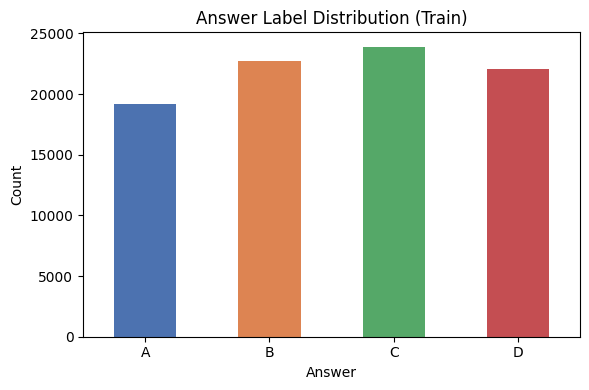

answer
C    23891
B    22726
D    22103
A    19146
Name: count, dtype: int64


In [6]:
plt.figure(figsize=(6,4))
train_df['answer'].value_counts().sort_index().plot(kind='bar', color=['#4C72B0','#DD8452','#55A868','#C44E52'])
plt.title('Answer Label Distribution (Train)')
plt.xlabel('Answer')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{base}/notebooks/answer_distribution.png')
plt.show()
print(train_df['answer'].value_counts())

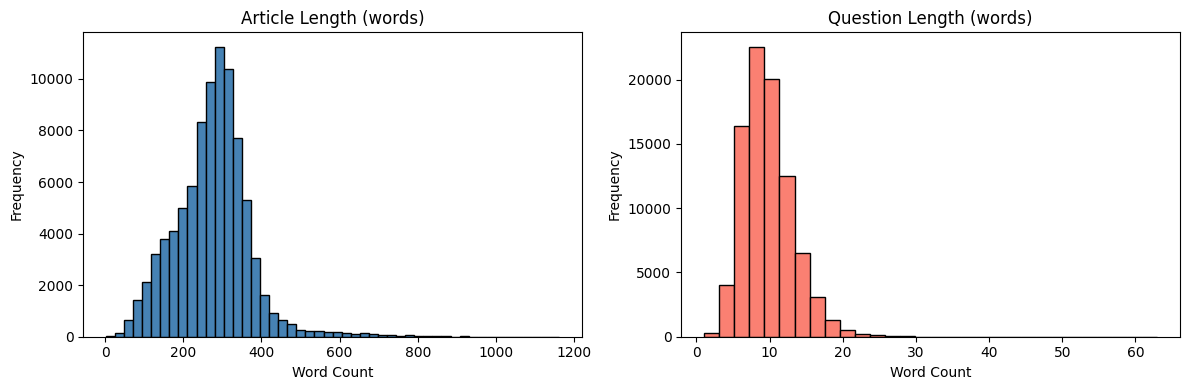

Article length stats:
count    87866.000000
mean       274.983702
std         97.881345
min          2.000000
25%        217.000000
50%        279.000000
75%        326.000000
max       1162.000000
Name: article_len, dtype: float64

Question length stats:
count    87866.000000
mean        10.008786
std          3.382040
min          1.000000
25%          8.000000
50%         10.000000
75%         12.000000
max         63.000000
Name: question_len, dtype: float64


In [7]:
train_df['article_len'] = train_df['article'].apply(lambda x: len(str(x).split()))
train_df['question_len'] = train_df['question'].apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(train_df['article_len'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Article Length (words)')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')

axes[1].hist(train_df['question_len'], bins=30, color='salmon', edgecolor='black')
axes[1].set_title('Question Length (words)')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig(f'{base}/notebooks/length_distributions.png')
plt.show()

print("Article length stats:")
print(train_df['article_len'].describe())
print("\nQuestion length stats:")
print(train_df['question_len'].describe())

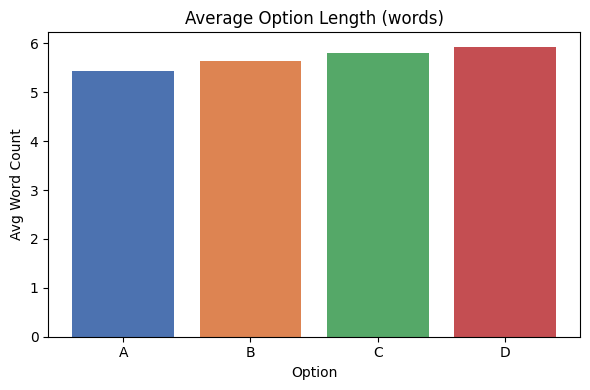

Average option lengths: {'A': np.float64(5.441251451073225), 'B': np.float64(5.643172558213643), 'C': np.float64(5.80772995242756), 'D': np.float64(5.931452438941115)}


In [8]:
for col in ['A','B','C','D']:
    train_df[f'{col}_len'] = train_df[col].apply(lambda x: len(str(x).split()))

avg_lens = {col: train_df[f'{col}_len'].mean() for col in ['A','B','C','D']}

plt.figure(figsize=(6,4))
plt.bar(avg_lens.keys(), avg_lens.values(), color=['#4C72B0','#DD8452','#55A868','#C44E52'])
plt.title('Average Option Length (words)')
plt.xlabel('Option')
plt.ylabel('Avg Word Count')
plt.tight_layout()
plt.savefig(f'{base}/notebooks/option_lengths.png')
plt.show()
print("Average option lengths:", avg_lens)

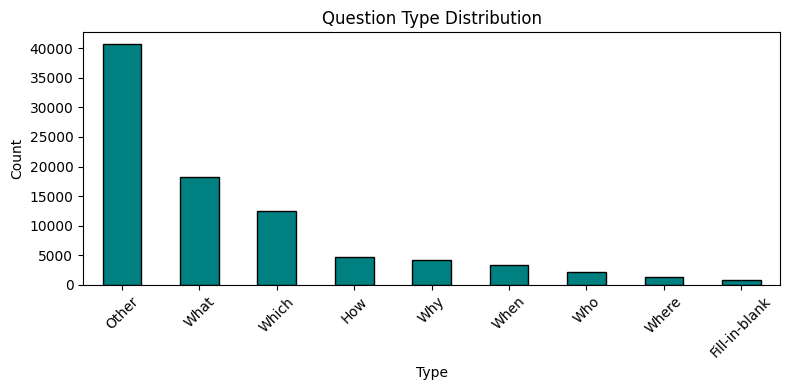

q_type
Other            40653
What             18268
Which            12509
How               4697
Why               4223
When              3311
Who               2152
Where             1256
Fill-in-blank      797
Name: count, dtype: int64


In [9]:
import re

def get_question_type(q):
    q = str(q).lower().strip()
    if q.startswith('_') or 'blank' in q:
        return 'Fill-in-blank'
    for w in ['what','which','how','who','where','when','why']:
        if w in q:
            return w.capitalize()
    return 'Other'

train_df['q_type'] = train_df['question'].apply(get_question_type)

plt.figure(figsize=(8,4))
train_df['q_type'].value_counts().plot(kind='bar', color='teal', edgecolor='black')
plt.title('Question Type Distribution')
plt.xlabel('Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f'{base}/notebooks/question_types.png')
plt.show()
print(train_df['q_type'].value_counts())

In [10]:
summary = pd.DataFrame({
    'Metric': [
        'Total Train Samples',
        'Total Test Samples',
        'Total Val Samples',
        'Avg Article Length (words)',
        'Avg Question Length (words)',
        'Most Common Answer',
        'Unique Question Types',
        'Missing Values'
    ],
    'Value': [
        len(train_df),
        len(test_df),
        len(val_df),
        round(train_df['article_len'].mean(), 1),
        round(train_df['question_len'].mean(), 1),
        train_df['answer'].value_counts().idxmax(),
        train_df['q_type'].nunique(),
        train_df.isnull().sum().sum()
    ]
})

print(summary.to_string(index=False))
summary.to_csv(f'{base}/notebooks/summary_stats.csv', index=False)
print("\n✅ EDA Complete! All plots saved to notebooks folder.")

                     Metric  Value
        Total Train Samples  87866
         Total Test Samples  87866
          Total Val Samples  87866
 Avg Article Length (words)  275.0
Avg Question Length (words)   10.0
         Most Common Answer      C
      Unique Question Types      9
             Missing Values     14

✅ EDA Complete! All plots saved to notebooks folder.
